# Detecção de áreas queimadas com Random Forest sobre Landsat 8/9

Este notebook implementa um classificador **pixel a pixel** de cicatrizes de
queimada em pares de imagens Landsat. A ideia é simples: o fogo derruba a
refletância no infravermelho próximo e levanta a do SWIR — diferença essa
capturada pelo índice **dNBR** (`NBR` pré-fogo menos `NBR` pós-fogo). Sobre essa
única feature treinamos um **Random Forest**.

## Pipeline em uma linha

`raster pré + raster pós + máscara` → `dNBR` → `Random Forest (GridSearchCV)` → `máscara binária predita`

## O que cada cena faz no experimento

- **Cena de treino (`220_075/`)**: ajusta o RF e fornece um *holdout* interno
  (split estratificado) para um primeiro check de desempenho.
- **Cena cega (`221_074/`)**: nunca é vista durante o ajuste. Serve para medir
  o que o modelo *de fato* generaliza quando aplicado em outra área e em
  outra data.

## Por que estas escolhas e não outras

| Decisão | Motivo |
|---|---|
| Apenas `dNBR` como feature | Mantém paridade com o experimento RBF-SVM. RF em 1D ainda quebra a feature em vários thresholds, então não vira "achar o melhor corte fixo". |
| Sem `StandardScaler` | RF olha apenas a *ordem* dos valores; reescala monotônica não muda nada. |
| Subamostra ~50 mil pixels | Bootstrap em 50k já satura o ganho marginal e roda em segundos. |
| `GridSearchCV` sobre `n_estimators × max_depth × min_samples_leaf` | Cobre o trade-off variância × ruído × custo. `max_features` fica fixo (problema 1D). |
| `class_weight="balanced"` | Queimada é minoritária (~5 a 8% dos pixels válidos). Sem reponderar, o RF colapsa para "tudo não-queimada". |
| `oob_score=True` no refit | Estimativa de generalização *grátis* a partir das amostras fora do bootstrap. |
| Métrica de seleção: F1 da classe positiva | Pondera precision e recall sob desbalanceamento. |
| Métrica reportada: também κ de Cohen | Padrão em sensoriamento remoto (Congalton, 1991) — desconta concordância por acaso. |
| Baseline obrigatório | Threshold fixo de Key & Benson (`dNBR > 0.27`). Se o RF não bater isso, não justifica a complexidade. |
| `random_state=42` em todo lugar | Reprodutibilidade.

## 0. Dependências

A célula abaixo só garante que os pacotes estejam instalados. Se já estiverem,
o `pip` apenas confirma e segue.

In [1]:
!pip install numpy matplotlib rasterio scikit-learn

## 1. Imports, logger e seed

Tudo fica num único lugar: bibliotecas, configuração de log (preferimos
`logging` no lugar de `print` espalhado pelo pipeline) e a seed global que
torna o run reprodutível.

In [2]:
from __future__ import annotations

import logging
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.warp import Resampling, reproject

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Silencia warnings de divisão/NaN do numpy ao operar em rasters com nodata.
warnings.filterwarnings("ignore", category=RuntimeWarning)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("rf_burn")

RNG_SEED = 42
np.random.seed(RNG_SEED)

## 2. Caminhos dos rasters — única célula que o usuário precisa editar

Cada cena Landsat é descrita por três rasters:

- `nbr_pre`: NBR antes do evento.
- `nbr_post`: NBR depois do evento.
- `truth`: máscara binária (`0` = não queimada, `1` = queimada). Ground truth.

A cena `220_075` será usada para **ajuste do modelo** e a `221_074` é a
**cena cega** — só entra na avaliação final. A pasta `OUT_DIR` recebe
quaisquer GeoTIFFs auxiliares que você queira despejar depois.

In [3]:
@dataclass(frozen=True)
class LandsatScene:
    """Descritor leve de uma cena: nome + caminhos para os três rasters."""
    tag: str
    nbr_pre: Path
    nbr_post: Path
    truth: Path


# --- Cena usada para AJUSTAR o classificador ------------------------------
SCENE_FIT = LandsatScene(
    tag="220_075",
    nbr_pre=Path("220_075/img_pre/LC08_L2SP_220075_20240821_NBR.tif"),
    nbr_post=Path("220_075/img_pos/LC09_L2SP_220075_20240829_NBR.tif"),
    truth=Path("220_075/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
)

# --- Cena usada apenas no TESTE CEGO --------------------------------------
SCENE_BLIND = LandsatScene(
    tag="221_074",
    nbr_pre=Path("221_074/img_pre/LC09_L2SP_221074_20240820_NBR.tif"),
    nbr_post=Path("221_074/img_pos/LC08_L2SP_221074_20240828_NBR.tif"),
    truth=Path("221_074/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
)

OUT_DIR = Path("./saida_modelo_rf")
OUT_DIR.mkdir(parents=True, exist_ok=True)

log.info("Cena de ajuste : %s", SCENE_FIT.tag)
log.info("Cena cega      : %s", SCENE_BLIND.tag)
log.info("Diretório saída: %s", OUT_DIR)

14:21:47 [INFO] Cena de ajuste : 220_075
14:21:47 [INFO] Cena cega      : 221_074
14:21:47 [INFO] Diretório saída: saida_modelo_rf


## 3. Camada de leitura raster e cálculo do dNBR

Há um detalhe chato em rasters Landsat recortados manualmente: o pré e o pós
de uma mesma cena costumam ter *bounds* levemente diferentes (alguns pixels
de deslocamento) e cenas distintas podem estar em CRS diferentes. Subtrair
arrays com shapes ou georreferências distintas estoura.

A solução é **escolher um grid de referência** e reamostrar todo mundo para
ele. Adotamos a máscara como referência: ela é a verdade e todas as métricas
têm que viver no mesmo grid dela.

Funções nesta seção:

- `read_band` — lê uma banda como `float32`, transformando `nodata` em `NaN`.
- `read_warped_to_grid` — lê um raster reprojetado para o grid (CRS +
  transform + shape) de outro raster, com reamostragem bilinear.
- `read_truth_mask` — lê a máscara como `int8` mantendo `-1` para pixels
  inválidos.
- `build_delta_nbr` — orquestra: lê truth, alinha pré e pós ao grid dela,
  devolve `(dnbr, truth)`.
- `flatten_valid_pixels` — vetoriza os arrays 2D em `(X, y, mask_valid)`,
  descartando pixels com `NaN` no dNBR ou `-1` na máscara.

In [4]:
def read_band(path: Path, band_idx: int = 1) -> np.ndarray:
    """Lê uma banda como float32. Substitui o nodata declarado por NaN."""
    with rasterio.open(path) as src:
        arr = src.read(band_idx).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr


def read_warped_to_grid(src_path: Path, grid_ref_path: Path) -> np.ndarray:
    """Lê `src_path` já reamostrado para o grid de `grid_ref_path`.

    Usa reamostragem bilinear (índices contínuos como o NBR pedem).
    Pixels da fonte que não cobrem o destino ficam como NaN.
    """
    with rasterio.open(grid_ref_path) as ref:
        out_shape = ref.shape
        out_transform = ref.transform
        out_crs = ref.crs

    warped = np.full(out_shape, np.nan, dtype=np.float32)

    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=warped,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=out_transform,
            dst_crs=out_crs,
            resampling=Resampling.bilinear,
            src_nodata=src.nodata,
            dst_nodata=np.nan,
        )
    return warped


def read_truth_mask(path: Path) -> np.ndarray:
    """Lê a máscara binária. Codifica:  0 = não queimada, 1 = queimada, -1 = inválido."""
    raw = read_band(path)
    out = np.full(raw.shape, -1, dtype=np.int8)
    out[raw == 0] = 0
    out[raw == 1] = 1
    return out


def build_delta_nbr(scene: LandsatScene) -> tuple[np.ndarray, np.ndarray]:
    """Calcula `dNBR = NBR_pre - NBR_post` no grid da máscara da cena.

    Retorna `(dnbr_2d, truth_2d)`. Pixels com NaN em qualquer dos NBRs
    ficam como NaN no dNBR.
    """
    log.info("[%s] lendo máscara (ground truth)", scene.tag)
    truth = read_truth_mask(scene.truth)

    log.info("[%s] reamostrando NBR pré para o grid da máscara", scene.tag)
    nbr_pre = read_warped_to_grid(scene.nbr_pre, scene.truth)

    log.info("[%s] reamostrando NBR pós para o grid da máscara", scene.tag)
    nbr_post = read_warped_to_grid(scene.nbr_post, scene.truth)

    dnbr = nbr_pre - nbr_post
    log.info("[%s] dNBR shape=%s | truth shape=%s",
             scene.tag, dnbr.shape, truth.shape)
    return dnbr, truth


def flatten_valid_pixels(
    dnbr_2d: np.ndarray, truth_2d: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Vetoriza os arrays 2D e descarta pixels inválidos.

    Retorna:
        X_valid     — shape (N, 1) com o dNBR.
        y_valid     — shape (N,)   com 0/1.
        valid_mask  — shape (H*W,) booleana, marcando os pixels mantidos.
    """
    X = dnbr_2d.reshape(-1, 1)
    y = truth_2d.ravel()
    valid_mask = (y >= 0) & np.isfinite(X[:, 0])
    return X[valid_mask], y[valid_mask].astype(np.int8), valid_mask

## 4. Carregamento efetivo da cena de ajuste

Aqui as funções da seção anterior são executadas pela primeira vez. A partir
desta célula, `dnbr_fit` e `truth_fit` são arrays 2D no grid da máscara da
cena de treino, prontos para inspeção.

Reportamos também a contagem de pixels por classe — útil para confirmar o
desbalanceamento que motiva `class_weight="balanced"` mais à frente.

In [5]:
dnbr_fit, truth_fit = build_delta_nbr(SCENE_FIT)
fit_h, fit_w = truth_fit.shape

count_burn    = int((truth_fit == 1).sum())
count_unburn  = int((truth_fit == 0).sum())
count_invalid = int((truth_fit == -1).sum())
total_pix     = truth_fit.size

log.info(
    "[%s] %d x %d | queimada=%d (%.2f%%) | não queimada=%d (%.2f%%) | inválidos=%d",
    SCENE_FIT.tag, fit_h, fit_w,
    count_burn,   100 * count_burn   / total_pix,
    count_unburn, 100 * count_unburn / total_pix,
    count_invalid,
)

14:21:56 [INFO] [220_075] lendo máscara (ground truth)
14:21:56 [INFO] [220_075] reamostrando NBR pré para o grid da máscara
14:21:58 [INFO] [220_075] reamostrando NBR pós para o grid da máscara
14:21:59 [INFO] [220_075] dNBR shape=(7691, 7581) | truth shape=(7691, 7581)
14:21:59 [INFO] [220_075] 7691 x 7581 | queimada=3199001 (5.49%) | não queimada=37274412 (63.93%) | inválidos=17832058


## 5. Sanity check visual — o dNBR realmente separa as classes?

Antes de gastar tempo treinando qualquer coisa, vale uma checagem básica:
olhando para a distribuição do dNBR, as duas classes ficam em regiões
diferentes do eixo? Se não ficarem, nenhum classificador 1D vai resolver e a
escolha correta seria adicionar features.

Mostramos lado a lado:

1. O **mapa de dNBR** da cena de ajuste. Áreas vermelhas escuras correspondem
   a quedas grandes do NBR — candidatas a queimada.
2. Os **histogramas por classe** sobrepostos, com o threshold de Key & Benson
   (0.27) marcado para referência.

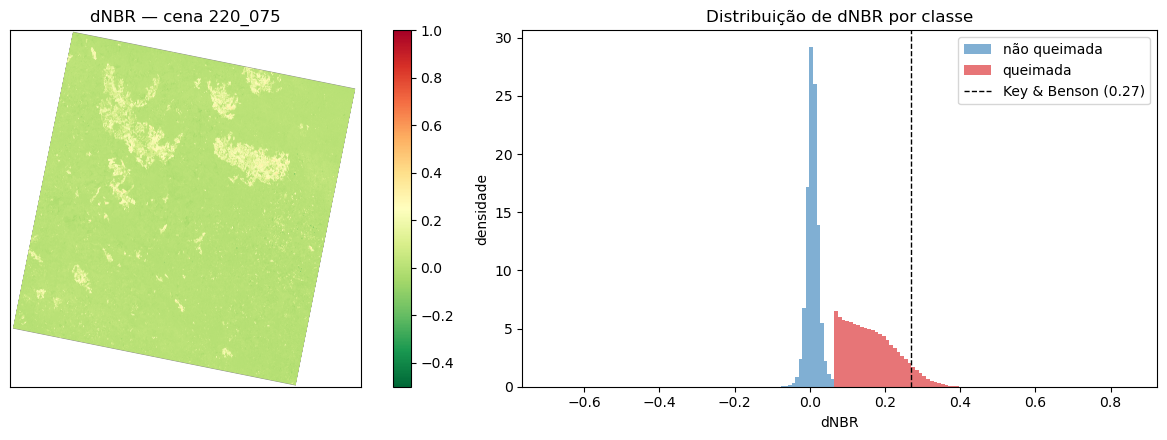

In [6]:
fig, panels = plt.subplots(1, 2, figsize=(14, 4.5))

# --- painel da esquerda: o mapa do dNBR -----------------------------------
img = panels[0].imshow(dnbr_fit, cmap="RdYlGn_r", vmin=-0.5, vmax=1.0)
panels[0].set_title(f"dNBR — cena {SCENE_FIT.tag}")
panels[0].set_xticks([]); panels[0].set_yticks([])
plt.colorbar(img, ax=panels[0], fraction=0.046)

# --- painel da direita: histogramas por classe ----------------------------
mask_keep   = (truth_fit >= 0) & np.isfinite(dnbr_fit)
dnbr_pixels = dnbr_fit[mask_keep]
truth_pixels = truth_fit[mask_keep]

palette = [
    (0, "#2c7bb6", "não queimada"),
    (1, "#d7191c", "queimada"),
]
for cls, color, label in palette:
    panels[1].hist(
        dnbr_pixels[truth_pixels == cls],
        bins=80, alpha=0.6, color=color, label=label, density=True,
    )

panels[1].axvline(0.27, ls="--", color="black", lw=1,
                  label="Key & Benson (0.27)")
panels[1].set_xlabel("dNBR")
panels[1].set_ylabel("densidade")
panels[1].set_title("Distribuição de dNBR por classe")
panels[1].legend()

plt.tight_layout(); plt.show()

## 6. Montagem do dataset — vetorizar, separar e subamostrar

Três passos, nesta ordem:

1. **Vetorizar e descartar pixels inválidos.** A função `flatten_valid_pixels`
   já remove pixels com NaN no dNBR ou marcados como `-1` na máscara.
2. **Holdout interno estratificado, 70/30.** A separação acontece *antes* de
   qualquer subamostragem, para que o conjunto de teste interno seja imune a
   vazamento.
3. **Subamostrar o conjunto de treino para ~50 mil pixels**, mantendo a
   proporção de classes. RF escala em $O(n \log n)$ por árvore, então
   subamostrar é mais por economia de tempo do que por necessidade.

O conjunto de teste interno mede o desempenho na **mesma cena** de treino,
em pixels que o modelo nunca viu. É um teste otimista (correlação espacial
forte) — daí a importância da cena cega lá no fim.

In [7]:
X_pool, y_pool, _ = flatten_valid_pixels(dnbr_fit, truth_fit)
log.info("Pixels válidos na cena de ajuste: %d (%.2f%% da cena)",
         X_pool.shape[0], 100 * X_pool.shape[0] / truth_fit.size)

# 1) split estratificado 70/30 (intocável até a avaliação interna)
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X_pool, y_pool,
    test_size=0.30,
    stratify=y_pool,
    random_state=RNG_SEED,
)

# 2) subamostragem do conjunto de DEV (treino + CV) para 50k pixels
SUBSAMPLE_SIZE = 50_000
if X_dev.shape[0] > SUBSAMPLE_SIZE:
    X_train, _, y_train, _ = train_test_split(
        X_dev, y_dev,
        train_size=SUBSAMPLE_SIZE,
        stratify=y_dev,
        random_state=RNG_SEED,
    )
else:
    X_train, y_train = X_dev, y_dev

log.info("Treino  : %d amostras | queimada=%.2f%%",
         len(y_train), 100 * y_train.mean())
log.info("Holdout : %d amostras | queimada=%.2f%%",
         len(y_holdout), 100 * y_holdout.mean())

14:22:31 [INFO] Pixels válidos na cena de ajuste: 40473413 (69.42% da cena)
14:23:00 [INFO] Treino  : 50000 amostras | queimada=7.90%
14:23:00 [INFO] Holdout : 12142024 amostras | queimada=7.90%


## 7. Utilitários de avaliação

Empacotamos em três funções tudo o que vamos repetir nas duas avaliações
(holdout interno e cena cega):

- `quick_scores`: imprime e devolve um dicionário com Accuracy, Precision,
  Recall, F1 e κ.
- `print_full_report`: o bloco completo — métricas, `classification_report`
  do sklearn e tabela comparativa contra o baseline.
- `plot_diagnostics`: matriz de confusão e curva ROC lado a lado.

Definir antes do treino só por organização: assim as células 8, 9 e 10 têm
foco no que importa.

In [8]:
def quick_scores(y_true: np.ndarray, y_pred: np.ndarray, *, header: str) -> dict[str, float]:
    """Imprime as métricas básicas e devolve um dict para uso programático."""
    scores = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "Kappa":     cohen_kappa_score(y_true, y_pred),
    }
    print(f"=== {header} ===")
    for k, v in scores.items():
        print(f"{k:<10}: {v:.4f}")
    return scores


def print_full_report(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    y_baseline: np.ndarray,
    *,
    scene_label: str,
) -> None:
    """Métricas + classification_report + tabela RF vs baseline lado a lado."""
    print(f"=== Random Forest — {scene_label} ===")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Kappa    : {cohen_kappa_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print()
    print(classification_report(
        y_true, y_pred,
        target_names=["não queimada", "queimada"],
        digits=4, zero_division=0,
    ))
    print()
    print(f"{'Métrica':<10} {'Baseline (dNBR>0.27)':>22}   {'RF':>10}   Δ")
    print("-" * 60)
    metric_fns = [
        ("Accuracy",  accuracy_score),
        ("Precision", precision_score),
        ("Recall",    recall_score),
        ("F1",        f1_score),
        ("Kappa",     cohen_kappa_score),
    ]
    for name, fn in metric_fns:
        kw = {"zero_division": 0} if fn in (precision_score, recall_score, f1_score) else {}
        b = fn(y_true, y_baseline, **kw)
        s = fn(y_true, y_pred,    **kw)
        sign = "+" if (s - b) >= 0 else ""
        print(f"{name:<10} {b:>22.4f}   {s:>10.4f}   ({sign}{s - b:.4f})")


def plot_diagnostics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    *,
    panel_title: str,
) -> None:
    """Matriz de confusão e curva ROC, em uma figura com dois painéis."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["não queimada", "queimada"]).plot(
        ax=axes[0], cmap="Blues", values_format="d", colorbar=False,
    )
    axes[0].set_title(f"Matriz de confusão — {panel_title}")

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
    axes[1].plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
    axes[1].set_title(f"ROC — {panel_title}")
    axes[1].legend(loc="lower right")

    plt.tight_layout(); plt.show()


def batch_predict(
    model, X: np.ndarray, *, chunk_size: int = 500_000, label: str = "predict",
) -> tuple[np.ndarray, np.ndarray]:
    """Aplica o modelo em chunks. Retorna (predições int8, prob. da classe 1 float32)."""
    n = X.shape[0]
    preds = np.empty(n, dtype=np.int8)
    proba = np.empty(n, dtype=np.float32)
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        sub = X[start:end]
        preds[start:end] = model.predict(sub).astype(np.int8)
        proba[start:end] = model.predict_proba(sub)[:, 1].astype(np.float32)
        log.info("%s: %d / %d (%.1f%%)", label, end, n, 100 * end / n)
    return preds, proba

## 8. Baseline obrigatório — threshold fixo de Key & Benson (2006)

A literatura clássica de severidade sugere que `dNBR > 0.27` já indica
severidade *low-to-moderate* ou superior. Esse é o número que o RF precisa
**ultrapassar** para justificar a complexidade adicional. Se ele não for
melhor que um corte fixo, o ganho não compensa.

Avaliamos o baseline **no mesmo holdout interno** que será usado para o RF,
para que a comparação seja apples-to-apples.

In [9]:
KB_THRESHOLD = 0.27   # Key & Benson (2006)

baseline_holdout = (X_holdout[:, 0] > KB_THRESHOLD).astype(np.int8)
_ = quick_scores(
    y_holdout, baseline_holdout,
    header=f"Baseline dNBR>{KB_THRESHOLD:.2f} no holdout interno {SCENE_FIT.tag}",
)

=== Baseline dNBR>0.27 no holdout interno 220_075 ===
Accuracy  : 0.9269
Precision : 1.0000
Recall    : 0.0754
F1        : 0.1403
Kappa     : 0.1307


## 9. Ajuste do Random Forest com `GridSearchCV`

Não há `Pipeline` com scaler aqui: como já foi dito, RF é invariante a
transformações monotônicas. O modelo entra direto.

### Espaço de busca

- **`n_estimators`** controla o número de árvores. Mais árvores derrubam a
  variância, mas com retornos decrescentes acima de algumas centenas.
- **`max_depth`** define a profundidade máxima. `None` deixa cada árvore
  crescer até as folhas serem puras; valores finitos servem de regularização.
- **`min_samples_leaf`** é, na prática, uma poda: folhas pequenas
  memorizam ruído.
- **`max_features`** fica fixo no default — só temos uma feature, não há o
  que sortear.

### Critério de seleção

`scoring="f1"` (F1 da classe positiva). Sob desbalanceamento forte, accuracy é
enganoso e F1 pondera bem precision e recall.

### Pós-busca

Depois do `GridSearchCV` escolher os melhores parâmetros, **refitamos** o
modelo com `oob_score=True`. As amostras *out-of-bag* dão uma estimativa
adicional de generalização, redundante com a CV mas barata.

In [10]:
rf_template = RandomForestClassifier(
    class_weight="balanced",
    random_state=RNG_SEED,
    n_jobs=-1,
    bootstrap=True,
)

search_space = {
    "n_estimators":     [200, 500],
    "max_depth":        [None, 10, 20],
    "min_samples_leaf": [1, 5, 20],
}

cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG_SEED)

cv_search = GridSearchCV(
    estimator=rf_template,
    param_grid=search_space,
    scoring="f1",
    cv=cv_splitter,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

n_combos = (
    len(search_space["n_estimators"])
    * len(search_space["max_depth"])
    * len(search_space["min_samples_leaf"])
)
log.info("GridSearchCV iniciado: %d combinações × 3 folds", n_combos)
cv_search.fit(X_train, y_train)

log.info("Melhores parâmetros : %s",   cv_search.best_params_)
log.info("F1 médio em CV      : %.4f", cv_search.best_score_)

# Refit final agora com OOB para uma segunda estimativa de generalização
best_params = cv_search.best_params_
rf_final = RandomForestClassifier(
    **best_params,
    class_weight="balanced",
    random_state=RNG_SEED,
    n_jobs=-1,
    bootstrap=True,
    oob_score=True,
)
rf_final.fit(X_train, y_train)
log.info("OOB score (refit final): %.4f", rf_final.oob_score_)

14:23:36 [INFO] GridSearchCV iniciado: 18 combinações × 3 folds


Fitting 3 folds for each of 18 candidates, totalling 54 fits


14:24:23 [INFO] Melhores parâmetros : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
14:24:23 [INFO] F1 médio em CV      : 1.0000
14:24:25 [INFO] OOB score (refit final): 1.0000


## 10. Avaliação 1 — holdout interno (mesma cena de treino)

Pixels que não entraram no ajuste, mas vêm da mesma cena. Esperamos que aqui
o RF brilhe — números na mesma cena são quase sempre superestimados em
relação à generalização real, por causa da forte correlação espacial.

Reportamos lado a lado **baseline × RF**. Se o RF não vence o baseline aqui,
não há por que esperar que vença na cena cega.

In [11]:
pred_holdout, proba_holdout = batch_predict(
    rf_final, X_holdout,
    label=f"holdout interno {SCENE_FIT.tag}",
)

print_full_report(
    y_holdout, pred_holdout, proba_holdout, baseline_holdout,
    scene_label=f"holdout interno {SCENE_FIT.tag}",
)

14:25:28 [INFO] holdout interno 220_075: 500000 / 12142024 (4.1%)
14:25:30 [INFO] holdout interno 220_075: 1000000 / 12142024 (8.2%)
14:25:31 [INFO] holdout interno 220_075: 1500000 / 12142024 (12.4%)
14:25:33 [INFO] holdout interno 220_075: 2000000 / 12142024 (16.5%)
14:25:35 [INFO] holdout interno 220_075: 2500000 / 12142024 (20.6%)
14:25:36 [INFO] holdout interno 220_075: 3000000 / 12142024 (24.7%)
14:25:38 [INFO] holdout interno 220_075: 3500000 / 12142024 (28.8%)
14:25:39 [INFO] holdout interno 220_075: 4000000 / 12142024 (32.9%)
14:25:41 [INFO] holdout interno 220_075: 4500000 / 12142024 (37.1%)
14:25:42 [INFO] holdout interno 220_075: 5000000 / 12142024 (41.2%)
14:25:44 [INFO] holdout interno 220_075: 5500000 / 12142024 (45.3%)
14:25:46 [INFO] holdout interno 220_075: 6000000 / 12142024 (49.4%)
14:25:47 [INFO] holdout interno 220_075: 6500000 / 12142024 (53.5%)
14:25:49 [INFO] holdout interno 220_075: 7000000 / 12142024 (57.7%)
14:25:50 [INFO] holdout interno 220_075: 7500000 / 

=== Random Forest — holdout interno 220_075 ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000
Kappa    : 1.0000
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

não queimada     1.0000    1.0000    1.0000  11182324
    queimada     1.0000    1.0000    1.0000    959700

    accuracy                         1.0000  12142024
   macro avg     1.0000    1.0000    1.0000  12142024
weighted avg     1.0000    1.0000    1.0000  12142024


Métrica      Baseline (dNBR>0.27)           RF   Δ
------------------------------------------------------------
Accuracy                   0.9269       1.0000   (+0.0731)
Precision                  1.0000       1.0000   (+0.0000)
Recall                     0.0754       1.0000   (+0.9245)
F1                         0.1403       1.0000   (+0.8597)
Kappa                      0.1307       1.0000   (+0.8693)


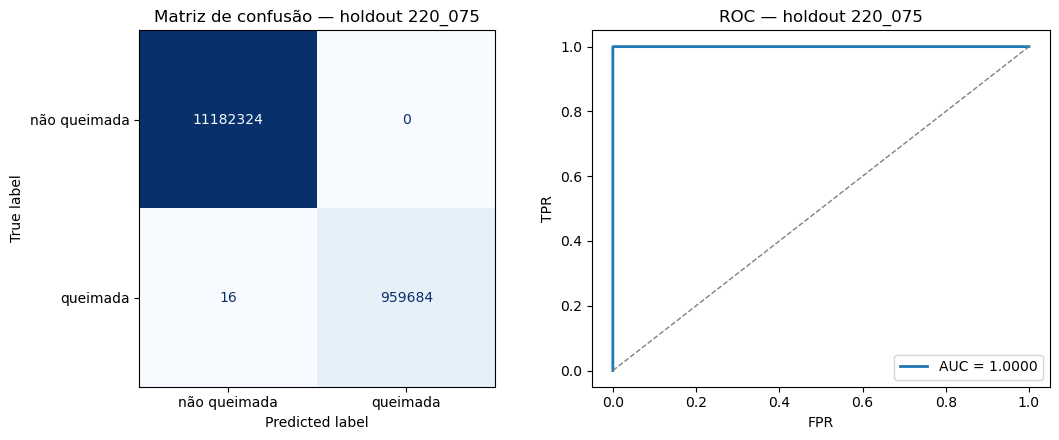

In [12]:
plot_diagnostics(
    y_holdout, pred_holdout, proba_holdout,
    panel_title=f"holdout {SCENE_FIT.tag}",
)

## 11. Avaliação 2 — cena cega (`221_074`)

Esse é o teste honesto. A cena `221_074` tem outra geografia, outro par de
sensores Landsat 8/9 (ordem invertida em relação à cena de treino), outra
data e até outro CRS. Tudo isso mexe na fenologia, na atmosfera e no
georreferenciamento.

Quedas grandes em **κ** ou em **recall** comparado ao holdout interno
indicam *domain shift* — sinal de que o RF aprendeu detalhes específicos da
cena de ajuste que não viajam bem.

In [13]:
dnbr_blind, truth_blind = build_delta_nbr(SCENE_BLIND)
blind_h, blind_w = truth_blind.shape

X_blind, y_blind, _ = flatten_valid_pixels(dnbr_blind, truth_blind)
log.info(
    "[%s] %d x %d | válidos=%d (%.2f%%) | queimada=%.2f%%",
    SCENE_BLIND.tag, blind_h, blind_w,
    X_blind.shape[0], 100 * X_blind.shape[0] / truth_blind.size,
    100 * y_blind.mean(),
)

14:26:45 [INFO] [221_074] lendo máscara (ground truth)
14:26:46 [INFO] [221_074] reamostrando NBR pré para o grid da máscara
14:26:47 [INFO] [221_074] reamostrando NBR pós para o grid da máscara
14:26:49 [INFO] [221_074] dNBR shape=(7821, 7721) | truth shape=(7821, 7721)
14:26:49 [INFO] [221_074] 7821 x 7721 | válidos=40137022 (66.47%) | queimada=4.89%


### Predição em chunks e relatório

Em cenas inteiras o número de pixels válidos pode passar de algumas dezenas
de milhões. `batch_predict` faz a inferência em fatias de 500 mil pixels para
manter a memória sob controle e mostrar progresso.

In [14]:
pred_blind, proba_blind = batch_predict(
    rf_final, X_blind,
    label=f"cena cega {SCENE_BLIND.tag}",
)
baseline_blind = (X_blind[:, 0] > KB_THRESHOLD).astype(np.int8)

print_full_report(
    y_blind, pred_blind, proba_blind, baseline_blind,
    scene_label=f"cena cega {SCENE_BLIND.tag}",
)

14:27:38 [INFO] cena cega 221_074: 500000 / 40137022 (1.2%)
14:27:39 [INFO] cena cega 221_074: 1000000 / 40137022 (2.5%)
14:27:40 [INFO] cena cega 221_074: 1500000 / 40137022 (3.7%)
14:27:41 [INFO] cena cega 221_074: 2000000 / 40137022 (5.0%)
14:27:43 [INFO] cena cega 221_074: 2500000 / 40137022 (6.2%)
14:27:45 [INFO] cena cega 221_074: 3000000 / 40137022 (7.5%)
14:27:46 [INFO] cena cega 221_074: 3500000 / 40137022 (8.7%)
14:27:48 [INFO] cena cega 221_074: 4000000 / 40137022 (10.0%)
14:27:49 [INFO] cena cega 221_074: 4500000 / 40137022 (11.2%)
14:27:51 [INFO] cena cega 221_074: 5000000 / 40137022 (12.5%)
14:27:52 [INFO] cena cega 221_074: 5500000 / 40137022 (13.7%)
14:27:54 [INFO] cena cega 221_074: 6000000 / 40137022 (14.9%)
14:27:55 [INFO] cena cega 221_074: 6500000 / 40137022 (16.2%)
14:27:57 [INFO] cena cega 221_074: 7000000 / 40137022 (17.4%)
14:27:58 [INFO] cena cega 221_074: 7500000 / 40137022 (18.7%)
14:28:00 [INFO] cena cega 221_074: 8000000 / 40137022 (19.9%)
14:28:01 [INFO] 

=== Random Forest — cena cega 221_074 ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000
Kappa    : 1.0000
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

não queimada     1.0000    1.0000    1.0000  38176151
    queimada     1.0000    1.0000    1.0000   1960871

    accuracy                         1.0000  40137022
   macro avg     1.0000    1.0000    1.0000  40137022
weighted avg     1.0000    1.0000    1.0000  40137022


Métrica      Baseline (dNBR>0.27)           RF   Δ
------------------------------------------------------------
Accuracy                   0.9545       1.0000   (+0.0455)
Precision                  1.0000       1.0000   (+0.0000)
Recall                     0.0681       1.0000   (+0.9319)
F1                         0.1276       1.0000   (+0.8724)
Kappa                      0.1221       1.0000   (+0.8779)


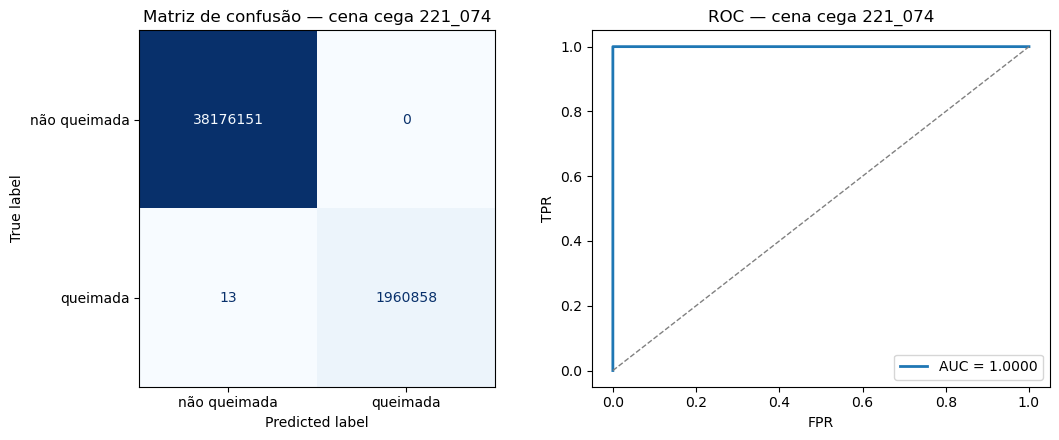

In [15]:
plot_diagnostics(
    y_blind, pred_blind, proba_blind,
    panel_title=f"cena cega {SCENE_BLIND.tag}",
)

In [16]:
# para cada pixel válido da cena de treino, ver se há sobreposição de dNBR entre classes
mask_keep = (truth_fit >= 0) & np.isfinite(dnbr_fit)
dnbr_burn   = dnbr_fit[mask_keep & (truth_fit == 1)]
dnbr_unburn = dnbr_fit[mask_keep & (truth_fit == 0)]
print("queimada   : min={:.3f}  max={:.3f}".format(dnbr_burn.min(),   dnbr_burn.max()))
print("não queim. : min={:.3f}  max={:.3f}".format(dnbr_unburn.min(), dnbr_unburn.max()))
# se min(queimada) > max(não queimada), as classes estão linearmente separáveis em dNBR

queimada   : min=0.065  max=0.847
não queim. : min=-0.688  max=0.065
